In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
# from fem_sim.tct_tractions import TCTExtractTractions

In [2]:
colors_ordered = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
]

def make_plot(ax, data, data_range, linestyle='-'):
    for i, j in enumerate(data_range):
        ax.plot(data[:, j], linestyle=linestyle, color=colors_ordered[i % len(colors_ordered)])

In [3]:
freq = 740
data_version = "benchmark"

In [5]:
# tct = TCTExtractTractions(frequency=freq, constitutive_model="plastic", configuration=data_version)
# tct.run()

In [6]:
# from sklearn.decomposition import PCA

# with open(f"training_data/plastic_top_{data_version}_for_pca.npz", "rb") as f:
#     data = np.load(f)
#     plastic_top = data[list(data.keys())[0]]

# pca = PCA(n_components=1)
# pca.fit(plastic_top)

In [7]:
# tct_data_internal = pca.transform(tct.data_plastic_top)

In [8]:
# with open(f"results/tct_results_in_{data_version}_freq_{freq}.npy", "wb") as f:
#     np.save(f, tct.data_in)

# with open(f"results/tct_results_out_{data_version}_freq_{freq}.npy", "wb") as f:
#     np.save(f, tct.data_out)

# with open(f"results/tct_results_internal_{data_version}_freq_{freq}.npy", "wb") as f:
#     np.save(f, tct_data_internal)

In [4]:
with open(f"results/tct_results_in_{data_version}_freq_{freq}.npy", "rb") as f:
    tct_data_in = np.load(f)

with open(f"results/tct_results_out_{data_version}_freq_{freq}.npy", "rb") as f:
    tct_data_out = np.load(f)

with open(f"results/tct_results_internal_{data_version}_freq_{freq}.npy", "rb") as f:
    tct_data_internal = np.load(f)

In [5]:
version = f"{data_version}_spils_net_v03_freq{freq}"
# version = f"{data_version}_fixed_fem"

with open(f"results/sim_results_in_{version}.npy", "rb") as f:
    sim_results_in = np.load(f)

with open(f"results/sim_results_out_{version}.npy", "rb") as f:
    sim_results_out = np.load(f)

try:
    with open(f"results/sim_results_internal_{version}.npy", "rb") as f:
        sim_results_internal = np.load(f)
except FileNotFoundError:
    sim_results_internal = None

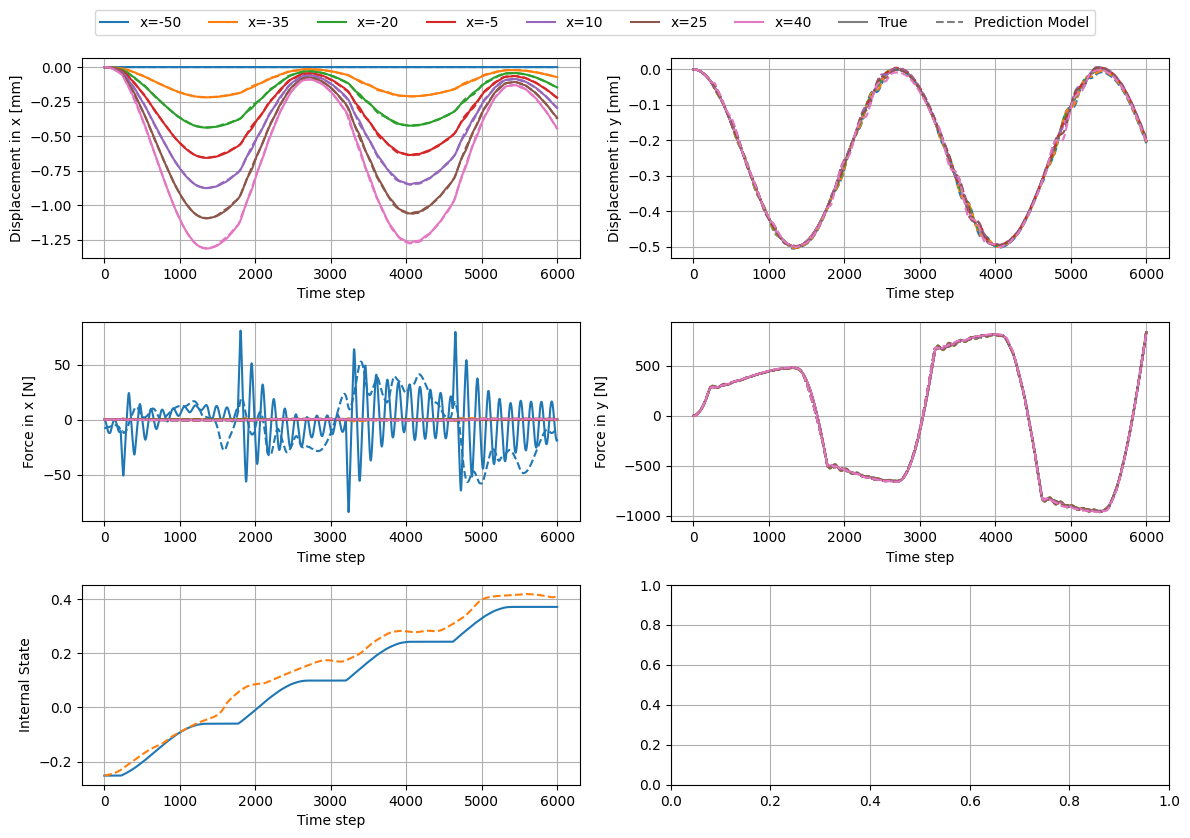

In [6]:
show_predictions = True

num_points = tct_data_in.shape[1] // 3
if data_version == "benchmark":
    nodes_plot = 6
else:
    nodes_plot = 16


fig, axs = plt.subplots(3, 2, figsize=(12, 8))

axs[0, 0].set_ylabel('Displacement in x [mm]')
axs[0, 0].set_xlabel("Time step")

axs[0, 1].set_ylabel('Displacement in y [mm]')
axs[0, 1].set_xlabel("Time step")

axs[1, 0].set_ylabel('Force in x [N]')
axs[1, 0].set_xlabel("Time step")

axs[1, 1].set_ylabel('Force in y [N]')
axs[1, 1].set_xlabel("Time step")

axs[2, 0].set_ylabel('Internal State')
axs[2, 0].set_xlabel("Time step")

make_plot(axs[0, 0], tct_data_in, range(0, num_points, nodes_plot))
make_plot(axs[0, 1], tct_data_in, range(1, num_points, nodes_plot))
make_plot(axs[1, 0], tct_data_out, range(0, num_points, nodes_plot))
make_plot(axs[1, 1], tct_data_out, range(1, num_points, nodes_plot))
axs[2, 0].plot(tct_data_internal)

if show_predictions:

    make_plot(axs[0, 0], sim_results_in, range(0, num_points, nodes_plot), linestyle='--')
    make_plot(axs[0, 1], sim_results_in, range(1, num_points, nodes_plot), linestyle='--')
    make_plot(axs[1, 0], sim_results_out, range(0, num_points, nodes_plot), linestyle='--')
    make_plot(axs[1, 1], sim_results_out, range(1, num_points, nodes_plot), linestyle='--')
    try:
        axs[2, 0].plot(sim_results_internal, linestyle="--")
    except Exception as e:
        pass

fig.legend(
    handles=[
        mlines.Line2D([], [], color=colors_ordered[0], label="x=-50"),
        mlines.Line2D([], [], color=colors_ordered[1], label="x=-35"),
        mlines.Line2D([], [], color=colors_ordered[2], label="x=-20"),
        mlines.Line2D([], [], color=colors_ordered[3], label="x=-5"),
        mlines.Line2D([], [], color=colors_ordered[4], label="x=10"),
        mlines.Line2D([], [], color=colors_ordered[5], label="x=25"),
        mlines.Line2D([], [], color=colors_ordered[6], label="x=40"),
        mlines.Line2D([], [], color="tab:grey", label="True"),
        mlines.Line2D([], [], color="tab:grey", label="Prediction Model", linestyle="--"),
    ], loc="upper center", ncol=9, bbox_to_anchor=(0.5, 1.05))

for ax in axs.flat:
    ax.grid()

fig.tight_layout()

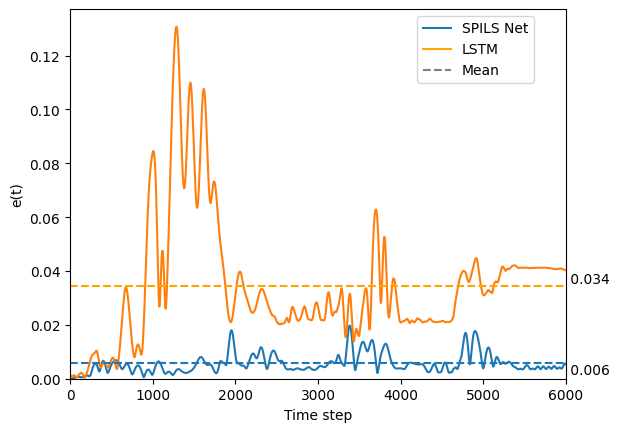

In [8]:
with open(f"results/sim_results_error_{data_version}_lstm_v02.npy", "rb") as f:
    lstm_error = np.load(f)

with open(f"results/sim_results_error_{data_version}_spils_net_v03_freq{freq}.npy", "rb") as f:
    spils_error = np.load(f)

plt.plot(spils_error, label="SPILS Net")
plt.plot(lstm_error, label="LSTM")

skip_steps = 0

spils_mean = np.mean(spils_error[skip_steps:])
lstm_mean = np.mean(lstm_error[skip_steps:])

y_lim = np.max(np.concatenate((spils_error[skip_steps:], lstm_error[skip_steps:]))) * 1.05

if spils_mean < lstm_mean:
    spils_text_va = 'top'
    lstm_text_va = 'bottom'
else:
    spils_text_va = 'bottom'
    lstm_text_va = 'top'

plt.hlines(y=spils_mean, xmin=0, xmax=spils_error.shape[0], linestyles='--')
plt.text(spils_error.shape[0], spils_mean, f' {spils_mean:.3f}', va=spils_text_va)

plt.hlines(y=lstm_mean, xmin=0, xmax=spils_error.shape[0], colors='orange', linestyles='--')
plt.text(spils_error.shape[0], lstm_mean, f' {lstm_mean:.3f}', va=lstm_text_va)

plt.ylim(0, y_lim)
plt.xlim(0, spils_error.shape[0])
plt.legend(handles=[
    mlines.Line2D([], [], label='SPILS Net'),
    mlines.Line2D([], [], color='orange', label='LSTM'),
    mlines.Line2D([], [], color='tab:gray', linestyle='--', label='Mean'),
], loc=(0.7, 0.8)) 
plt.xlabel("Time step")
plt.ylabel("e(t)")
plt.show()